# Experiment: Predicting Concrete Compressive Strength from Mix Design

This notebook implements the plan in `methodology.md`.

**Research question.** How accurately can compressive strength (MPa) be predicted from mix proportions and curing age for mixtures the model has never seen, and do tree ensembles with ratio features outperform a linear baseline?

**Sections**
1. Setup and data loading
2. Exploratory analysis
3. Data cleaning
4. Feature engineering
5. Grouped train/test split
6. Model training (Linear Regression, Random Forest, Gradient Boosting)
7. Evaluation (RMSE, MAE, R²)
8. Leakage check: grouped versus random split
9. Findings

## 1. Setup and data loading

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (GroupShuffleSplit, GroupKFold, RandomizedSearchCV,
                                     cross_validate, train_test_split)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.precision", 3)

In [2]:
raw = pd.read_csv("data/Concrete_Data.csv")
print("Shape:", raw.shape)
raw.head()

Shape: (1030, 9)


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.053
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296


In [3]:
# Short, consistent column names
COLS = ["cement", "slag", "fly_ash", "water", "superplasticizer",
        "coarse_agg", "fine_agg", "age", "strength"]
df = raw.copy()
df.columns = COLS
MIX = COLS[:7]          # the seven ingredient quantities (kg/m3)
TARGET = "strength"     # MPa
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cement            1030 non-null   float64
 1   slag              1030 non-null   float64
 2   fly_ash           1030 non-null   float64
 3   water             1030 non-null   float64
 4   superplasticizer  1030 non-null   float64
 5   coarse_agg        1030 non-null   float64
 6   fine_agg          1030 non-null   float64
 7   age               1030 non-null   int64  
 8   strength          1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


## 2. Exploratory analysis

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
cement,1030.0,281.166,104.507,102.000,192.375,272.900,350.000,540.000
slag,1030.0,73.895,86.279,0.000,0.000,22.000,142.950,359.400
fly_ash,1030.0,54.187,63.996,0.000,0.000,0.000,118.270,200.100
water,1030.0,181.566,21.356,121.750,164.900,185.000,192.000,247.000
superplasticizer,1030.0,6.203,5.973,0.000,0.000,6.350,10.160,32.200
coarse_agg,1030.0,972.919,77.754,801.000,932.000,968.000,1029.400,1145.000
fine_agg,1030.0,773.579,80.175,594.000,730.950,779.510,824.000,992.600
age,1030.0,45.662,63.170,1.000,7.000,28.000,56.000,365.000
strength,1030.0,35.818,16.706,2.332,23.707,34.443,46.136,82.599


In [5]:
summary = pd.DataFrame({
    "missing": df.isna().sum(),
    "zeros": (df == 0).sum(),
    "negative": (df < 0).sum(),
})
summary

,missing,zeros,negative
cement,0,0,0
slag,0,466,0
fly_ash,0,566,0
water,0,0,0
superplasticizer,0,379,0
coarse_agg,0,0,0
fine_agg,0,0,0
age,0,0,0
strength,0,0,0


Zeros appear only in slag, fly ash, and superplasticizer. They mean the ingredient was not used, so they are kept as real values rather than treated as missing.

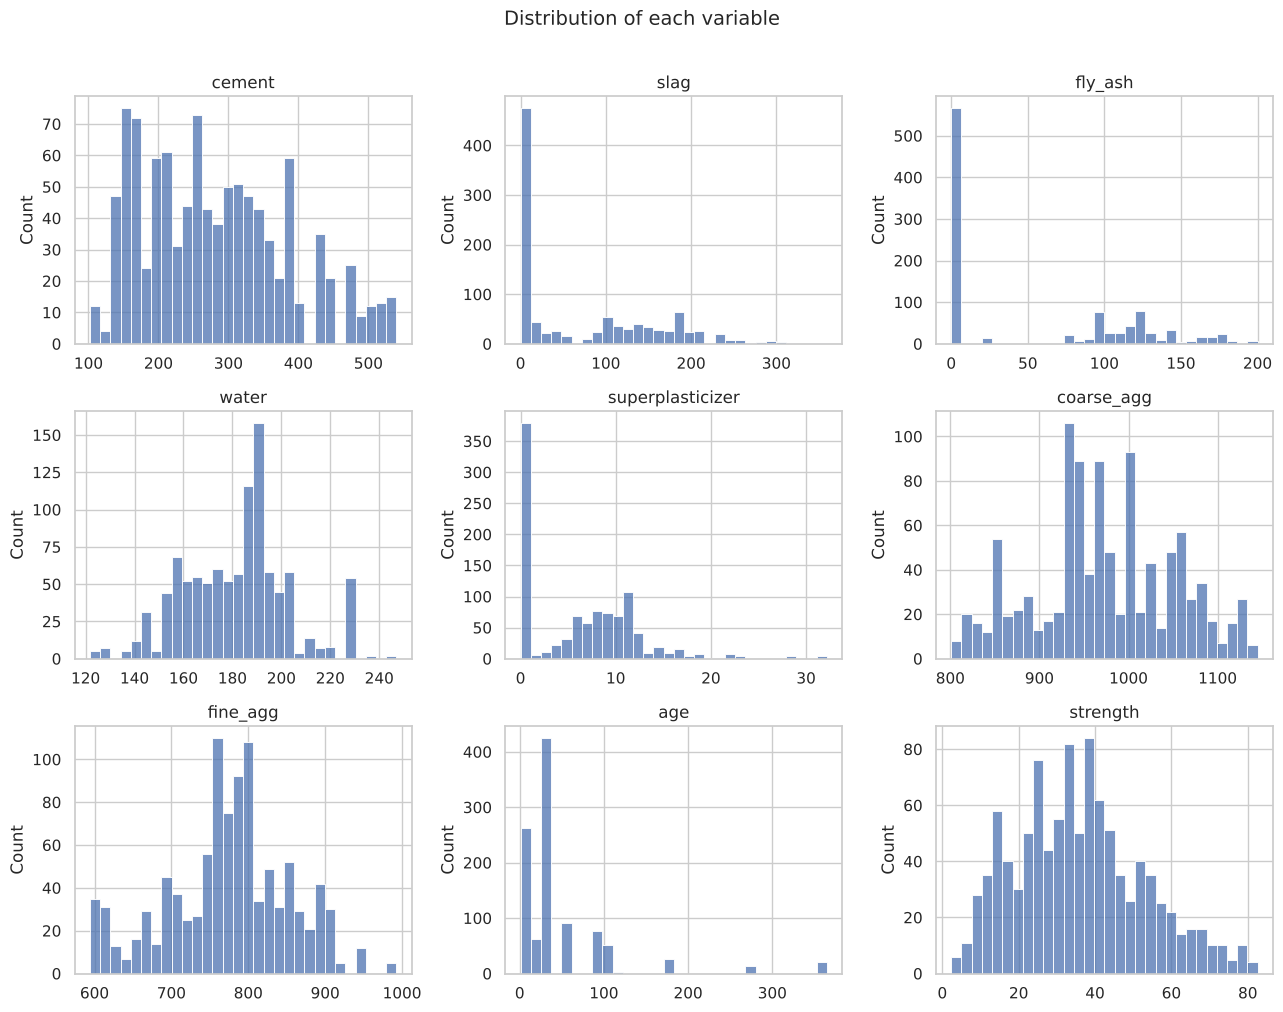

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ax, col in zip(axes.ravel(), COLS):
    sns.histplot(df[col], bins=30, ax=ax, color="#4C72B0")
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("Distribution of each variable", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

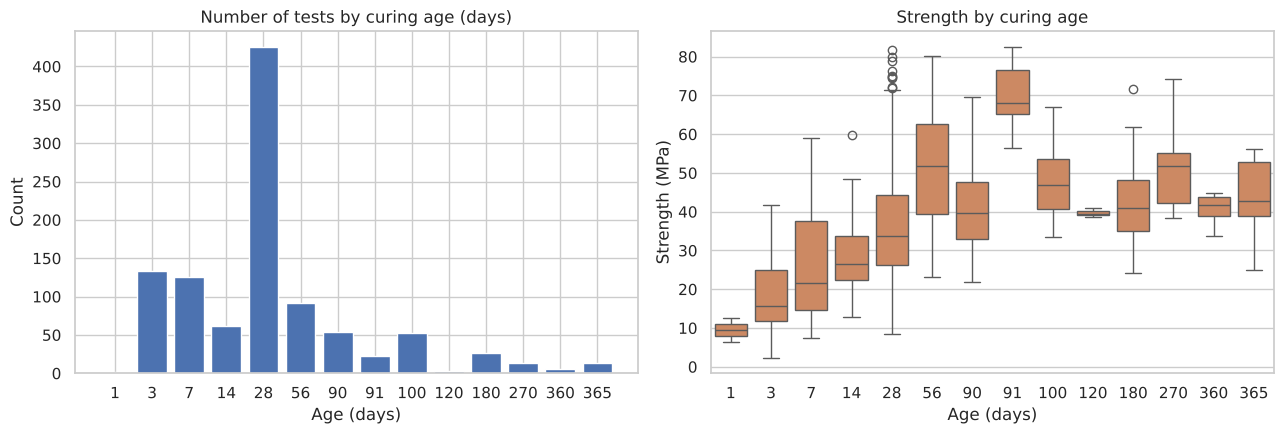

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
age_counts = df["age"].value_counts().sort_index()
axes[0].bar(age_counts.index.astype(str), age_counts.values, color="#4C72B0")
axes[0].set_title("Number of tests by curing age (days)")
axes[0].set_xlabel("Age (days)")
axes[0].set_ylabel("Count")
sns.boxplot(data=df, x="age", y="strength", ax=axes[1], color="#DD8452")
axes[1].set_title("Strength by curing age")
axes[1].set_xlabel("Age (days)")
axes[1].set_ylabel("Strength (MPa)")
plt.tight_layout()
plt.show()

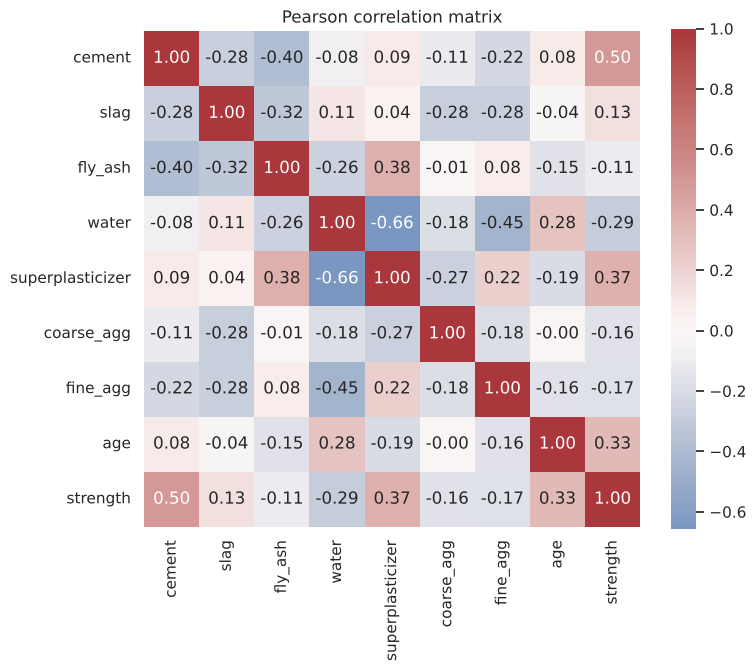

In [8]:
plt.figure(figsize=(8, 6.5))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="vlag", center=0, square=True)
plt.title("Pearson correlation matrix")
plt.show()

**Observations.** Strength is positively correlated with cement, superplasticizer and age, and negatively with water. Age is highly skewed, with most tests at 28 days and few beyond 120 days. The relationship with age is clearly nonlinear (rapid early gain, then a plateau), which supports a log-age feature and nonlinear models.

## 3. Data cleaning

In [9]:
n0 = len(df)
dup_rows = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f"Exact duplicate rows removed: {dup_rows}  ({n0} -> {len(df)})")

Exact duplicate rows removed: 25  (1030 -> 1005)


In [10]:
# Replicate tests: the same mixture at the same age with different strength values
rep_mask = df.duplicated(MIX + ["age"], keep=False)
print("Rows that are replicate tests of the same mixture and age:", rep_mask.sum())
df[rep_mask].sort_values(MIX + ["age"]).head(10)

Rows that are replicate tests of the same mixture and age: 18


,cement,slag,fly_ash,water,superplasticizer,coarse_agg,fine_agg,age,strength
501,359.0,19.0,141.0,154.0,10.91,942.0,801.0,3,25.117
502,359.0,19.0,141.0,154.0,10.91,942.0,801.0,3,23.639
503,359.0,19.0,141.0,154.0,10.91,942.0,801.0,7,35.754
504,359.0,19.0,141.0,154.0,10.91,942.0,801.0,7,38.611
499,359.0,19.0,141.0,154.0,10.91,942.0,801.0,28,62.935
500,359.0,19.0,141.0,154.0,10.91,942.0,801.0,28,59.495
505,359.0,19.0,141.0,154.0,10.91,942.0,801.0,56,68.751
506,359.0,19.0,141.0,154.0,10.91,942.0,801.0,56,66.781
99,362.6,189.0,0.0,164.9,11.60,944.7,755.8,7,55.896
105,362.6,189.0,0.0,164.9,11.60,944.7,755.8,7,22.897


In [11]:
# Average replicates so each mixture-age pair appears once
n1 = len(df)
df = df.groupby(MIX + ["age"], as_index=False)[TARGET].mean()
print(f"After averaging replicates: {n1} -> {len(df)} rows")

After averaging replicates: 1005 -> 996 rows


In [12]:
# Physical plausibility checks
assert (df[COLS] >= 0).all().all(), "negative quantities found"
assert df["cement"].gt(0).all(), "cement must be present"
assert df["age"].between(1, 365).all(), "age out of range"
assert df[TARGET].gt(0).all(), "non-positive strength"

# Outliers by the 1.5 x IQR rule: flagged, not removed
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()

pd.Series({c: iqr_outliers(df[c]) for c in COLS}, name="IQR outliers (kept)").to_frame().T

,cement,slag,fly_ash,water,superplasticizer,coarse_agg,fine_agg,age,strength
IQR outliers (kept),0,2,0,16,10,0,5,62,9


Outliers are kept. The flagged strength values are high-strength mixtures and the flagged ages are long-term tests (180 to 365 days), both of which are physically valid. Removing them would bias the model towards ordinary mixes.

In [13]:
# Mixture ID: one ID per unique combination of the seven ingredients
df["mix_id"] = df.groupby(MIX).ngroup()
print("Clean rows:", len(df))
print("Distinct mixtures:", df["mix_id"].nunique())
print("Mean tests per mixture:", round(len(df) / df["mix_id"].nunique(), 2))

Clean rows: 996
Distinct mixtures: 428
Mean tests per mixture: 2.33


Each mixture appears on average more than twice (at different ages). This dependence is why the test set is formed by holding out whole mixtures rather than random rows.